In [10]:
pip install lifelines

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4119 sha256=e286e7c04bef5a538f6b1f8cd4d37903c717087b6eb950cda0f1992621ff4e50
  Stored in directory: /home/rt334/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [lifelines]━ 3/7 [autograd]rwhals]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# Load the final integrated MEDUSA dataset
df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)

# Histology is stored as numeric codes in this file, so map them to readable labels.
# Sarcomatoid is included for completeness, although there is only one patient in that group.
hist_map = {1.0: 'Epithelioid', 2.0: 'Sarcomatoid', 3.0: 'Biphasic'}
df['Histology_clean'] = df['Histology'].map(hist_map)

# Methylation age-acceleration variables used throughout the analysis
age_acc_cols = [
    'ageAcc.Horvath', 'ageAcc.Hannum', 'ageAcc.Levine',
    'ageAcc.Hovarth2', 'ageAcc.PedBE', 'ageAcc.Wu',
    'ageAcc.TL', 'ageAcc.BLUP', 'ageAcc.EN'
]

# Cleaner clock names for figures and result tables
clock_display_names = {
    'ageAcc.Horvath': 'Horvath',
    'ageAcc.Hannum': 'Hannum',
    'ageAcc.Levine': 'Levine (PhenoAge)',
    'ageAcc.Hovarth2': 'Horvath (skin & blood)',
    'ageAcc.PedBE': 'PedBE',
    'ageAcc.Wu': 'Wu',
    'ageAcc.TL': 'Telomere Length (TL)',
    'ageAcc.BLUP': 'BLUP',
    'ageAcc.EN': 'Elastic Net (EN)'
}

/tmp/ipykernel_11219/1489323795.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Histology_clean'] = df['Histology'].map(hist_map)


In [2]:
# Run the same Mann-Whitney comparison across each categorical group
def run_group_tests(df, group_col, group_a, group_b, cols):
    results = []

    # Split the dataset into the two groups being compared
    a = df[df[group_col] == group_a]
    b = df[df[group_col] == group_b]

    for col in cols:
        a_vals = a[col].dropna()
        b_vals = b[col].dropna()

        # Skip comparisons where there are too few patients in either group
        if len(a_vals) < 3 or len(b_vals) < 3:
            continue

        stat, p = mannwhitneyu(a_vals, b_vals)

        # Store the sample sizes, medians and p-value for each clock
        results.append({
            'Epigenetic clock': clock_display_names[col],
            f'n ({group_a})': len(a_vals),
            f'n ({group_b})': len(b_vals),
            f'Median ({group_a})': round(a_vals.median(), 2),
            f'Median ({group_b})': round(b_vals.median(), 2),
            'p-value': p
        })

    res_df = pd.DataFrame(results)

    # Correct across the clocks tested within each comparison
    if len(res_df) > 0:
        res_df['FDR'] = multipletests(
            res_df['p-value'],
            method='fdr_bh'
        )[1]

        res_df['p-value'] = res_df['p-value'].round(3)
        res_df['FDR'] = res_df['FDR'].round(3)

    return res_df


# Compare methylation age acceleration between histological subtypes
hist_results = run_group_tests(
    df,
    'Histology_clean',
    'Epithelioid',
    'Biphasic',
    age_acc_cols
)

# Compare patients with and without recorded asbestos exposure
asb_results = run_group_tests(
    df,
    'Asbestos exposure',
    'Yes',
    'No',
    age_acc_cols
)

# Neoadjuvant treatment is the closest available treatment-related variable
df['Neoadjuvant'] = pd.to_numeric(
    df['Neoadjuvant'],
    errors='coerce'
)

neoadj_results = run_group_tests(
    df,
    'Neoadjuvant',
    0.0,
    1.0,
    age_acc_cols
)

# There was no direct treatment-response variable in the dataset.
# Neoadjuvant therefore records treatment received rather than whether a patient responded.

# Make sure the genomic grouping variables are numeric before testing them
for col, label in [
    ('Overall BAP1 IHC (1=positive/retained, 0=negative/loss)', 'BAP1'),
    ('DriverLoss 9p21 (CDKN2A,MTAP,IFNA)', 'MTAP'),
    ('Mutation NF2', 'NF2')
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# Test methylation age acceleration against the main genomic features
bap1_results = run_group_tests(
    df,
    'Overall BAP1 IHC (1=positive/retained, 0=negative/loss)',
    0.0,
    1.0,
    age_acc_cols
)

mtap_results = run_group_tests(
    df,
    'DriverLoss 9p21 (CDKN2A,MTAP,IFNA)',
    0.0,
    1.0,
    age_acc_cols
)

nf2_results = run_group_tests(
    df,
    'Mutation NF2',
    0.0,
    1.0,
    age_acc_cols
)

In [3]:
# Run Cox regression for each methylation clock against the survival outcome
def run_cox_tests(df, duration_col, event_col, cols):
    results = []

    for col in cols:
        sub = df[[col, duration_col, event_col]].dropna()
        sub.columns = ['clock', 'duration', 'event']

        # Skip survival models where too few patients have complete data
        if len(sub) < 10:
            continue

        cph = CoxPHFitter()
        cph.fit(sub, duration_col='duration', event_col='event')

        ci = cph.confidence_intervals_

        # Keep the hazard ratio, confidence interval and p-value for each clock
        results.append({
            'Epigenetic clock': clock_display_names[col],
            'n': len(sub),
            'HR': round(cph.hazard_ratios_['clock'], 3),
            'CI_lower': round(np.exp(ci.loc['clock', '95% lower-bound']), 3),
            'CI_upper': round(np.exp(ci.loc['clock', '95% upper-bound']), 3),
            'p-value': round(cph.summary.loc['clock', 'p'], 3),
        })

    res_df = pd.DataFrame(results)

    # Correct the survival p-values across all clocks tested
    if len(res_df) > 0:
        res_df['FDR'] = multipletests(
            res_df['p-value'],
            method='fdr_bh'
        )[1].round(3)

    return res_df


# Find the survival status and progression-free survival columns in the dataset
status_col = [c for c in df.columns if c.startswith('Status')][0]
os_col = 'Overall survival (Surgery-to-Death) in days'
pfs_col = [c for c in df.columns if 'progression' in c.lower() and 'survival' in c.lower()][0]


# Run the analysis for overall survival and progression-free survival
os_results = run_cox_tests(
    df,
    os_col,
    status_col,
    age_acc_cols
)

pfs_results = run_cox_tests(
    df,
    pfs_col,
    status_col,
    age_acc_cols
)

In [4]:
# Make the statistical result tables ready to drop into the report
def make_report_table(df, title, filename):

    # If nothing could be tested, don't try to build an empty table
    if len(df) == 0:
        print(
            f"SKIPPED {filename}: no clocks had enough patients per group to test "
            f"(too few patients in one group after requiring methylation data too)"
        )
        return

    # Scale the figure height depending on how many rows are in the result
    fig, ax = plt.subplots(figsize=(12, 0.55 * len(df) + 1.6))
    ax.axis('off')

    col_labels = list(df.columns)
    cell_text = df.astype(str).values.tolist()

    # Create the table from the dataframe
    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)

    # Style the header so it matches the rest of the report tables
    for col_idx in range(len(col_labels)):
        cell = table[0, col_idx]
        cell.set_facecolor('midnightblue')
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_edgecolor('white')

    # Use the FDR column to flag any results that survive correction
    fdr_col_idx = col_labels.index('FDR')

    for row_idx in range(1, len(df) + 1):
        fdr_val = float(cell_text[row_idx - 1][fdr_col_idx])

        for col_idx in range(len(col_labels)):
            cell = table[row_idx, col_idx]
            cell.set_edgecolor('gainsboro')
            cell.set_facecolor('whitesmoke' if row_idx % 2 == 0 else 'white')

            if fdr_val < 0.05:
                cell.set_text_props(fontweight='bold', color='darkgreen')

    # Add the title and save the final version
    plt.title(
        title,
        fontsize=12,
        fontweight='bold',
        pad=14,
        loc='left'
    )

    plt.tight_layout()
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.close()

    print(f"Saved {filename}")

In [5]:
# Create the final table image for each comparison
make_report_table(hist_results, "Table. Epigenetic age acceleration by histological subtype (Mann-Whitney U, FDR-corrected)", "table_histology.png")
make_report_table(neoadj_results, "Table. Epigenetic age acceleration by neoadjuvant treatment status (Mann-Whitney U, FDR-corrected)", "table_neoadjuvant.png")
make_report_table(asb_results, "Table. Epigenetic age acceleration by asbestos exposure status (Mann-Whitney U, FDR-corrected)", "table_asbestos.png")
make_report_table(bap1_results, "Table. Epigenetic age acceleration by BAP1 status (Mann-Whitney U, FDR-corrected)", "table_bap1.png")
make_report_table(mtap_results, "Table. Epigenetic age acceleration by MTAP status (Mann-Whitney U, FDR-corrected)", "table_mtap.png")
make_report_table(nf2_results, "Table. Epigenetic age acceleration by NF2 status (Mann-Whitney U, FDR-corrected)", "table_nf2.png")
make_report_table(os_results, "Table. Epigenetic age acceleration vs Overall Survival (Cox regression, FDR-corrected)", "table_os_cox.png")
make_report_table(pfs_results, "Table. Epigenetic age acceleration vs Progression-Free Survival (Cox regression, FDR-corrected)", "table_pfs_cox.png")


# Save the results behind each table as CSV files as well
for name, res in [
    ('histology', hist_results),
    ('neoadjuvant', neoadj_results),
    ('asbestos', asb_results),
    ('bap1', bap1_results),
    ('mtap', mtap_results),
    ('nf2', nf2_results),
    ('os_cox', os_results),
    ('pfs_cox', pfs_results)
]:
    res.to_csv(f'table_{name}_final.csv', index=False)


# Quick check that everything has finished running
print("\nAll 8 comparisons complete.")

Saved table_histology.png
SKIPPED table_neoadjuvant.png: no clocks had enough patients per group to test (too few patients in one group after requiring methylation data too)
Saved table_asbestos.png
Saved table_bap1.png
Saved table_mtap.png
Saved table_nf2.png
Saved table_os_cox.png
Saved table_pfs_cox.png

All 8 comparisons complete.


saved figure_clock_summary_heatmap.png


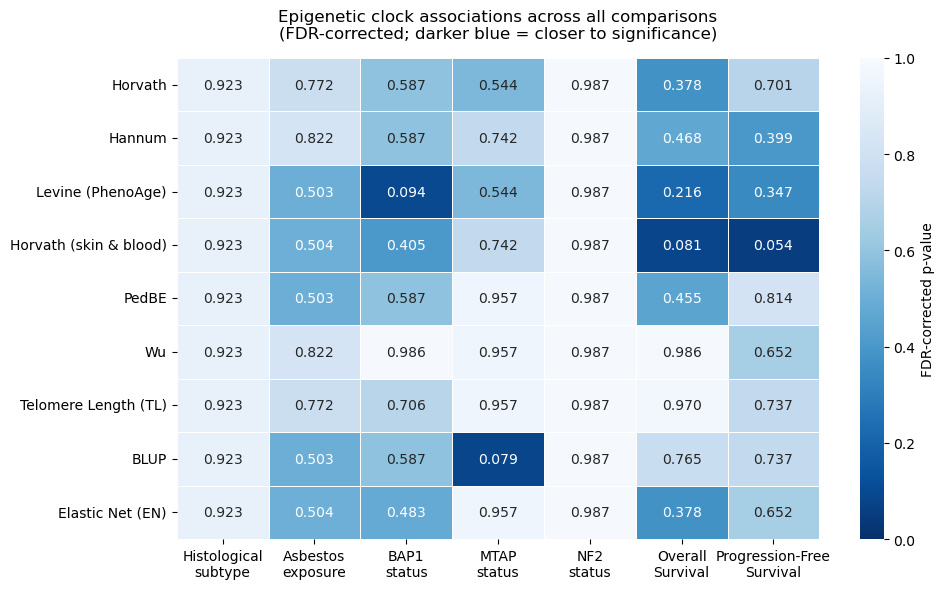

In [6]:
import seaborn as sns

# Bring the FDR results from each comparison together so the overall
# epigenetic pattern can be seen in one figure

clock_order = ['Horvath', 'Hannum', 'Levine (PhenoAge)', 'Horvath (skin & blood)',
               'PedBE', 'Wu', 'Telomere Length (TL)', 'BLUP', 'Elastic Net (EN)']

# Link each comparison to its final results table
comparisons = {
    'Histological\nsubtype': 'table_histology_final.csv',
    'Asbestos\nexposure': 'table_asbestos_final.csv',
    'BAP1\nstatus': 'table_bap1_final.csv',
    'MTAP\nstatus': 'table_mtap_final.csv',
    'NF2\nstatus': 'table_nf2_final.csv',
    'Overall\nSurvival': 'table_os_cox_final.csv',
    'Progression-Free\nSurvival': 'table_pfs_cox_final.csv',
}

# Set up an empty grid for the FDR values
heat_data = pd.DataFrame(index=clock_order, columns=list(comparisons.keys()), dtype=float)

# Read each results table and add the FDR values to the right place
for comp_label, csv_path in comparisons.items():
    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        clock = row['Epigenetic clock']

        if clock in clock_order:
            heat_data.loc[clock, comp_label] = row['FDR']

# Using a single blue scale to keep the figure easy to read
# Darker values show the associations that are closer to significance
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heat_data,
    annot=True,
    fmt='.3f',
    cmap='Blues_r',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'FDR-corrected p-value'},
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

# Finished the formatting and saved the figure
ax.set_title(
    'Epigenetic clock associations across all comparisons\n'
    '(FDR-corrected; darker blue = closer to significance)',
    pad=14
)

ax.set_xlabel('')
ax.set_ylabel('')

plt.xticks(rotation=0, ha='center')
plt.tight_layout()

plt.savefig(
    'figure_clock_summary_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

print('saved figure_clock_summary_heatmap.png')

saved figure_forest_os_pfs.png


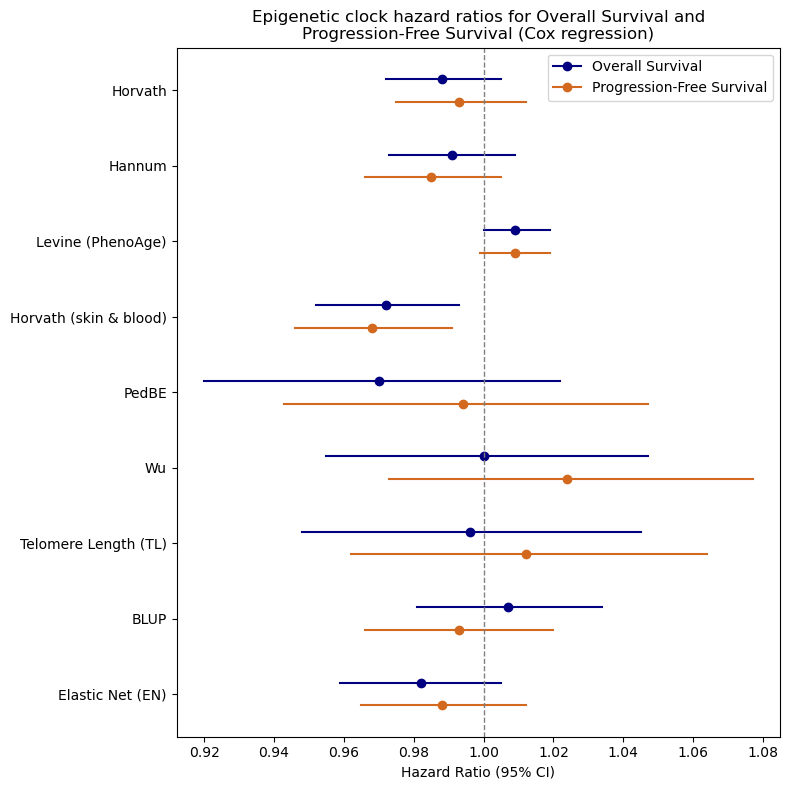

In [7]:
from matplotlib.lines import Line2D

# Build the forest plot directly from the saved Cox regression results

clock_order = ['Horvath', 'Hannum', 'Levine (PhenoAge)', 'Horvath (skin & blood)',
               'PedBE', 'Wu', 'Telomere Length (TL)', 'BLUP', 'Elastic Net (EN)']

# Load the overall survival and progression-free survival results
os_data = pd.read_csv('table_os_cox_final.csv')
pfs_data = pd.read_csv('table_pfs_cox_final.csv')

# Add a label so both outcomes can be plotted together
os_data['Outcome'] = 'OS'
pfs_data['Outcome'] = 'PFS'

data = pd.concat([os_data, pfs_data], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 8))

# Set the vertical position for each clock
y_positions = {clock: i for i, clock in enumerate(reversed(clock_order))}
offset = 0.15

# Use two clearly different colours for the survival outcomes
colors = {'OS': 'navy', 'PFS': 'chocolate'}

# Plot the hazard ratios and their confidence intervals
for outcome in ['OS', 'PFS']:
    sub = data[data['Outcome'] == outcome]

    for _, row in sub.iterrows():
        clock = row['Epigenetic clock']

        if clock not in y_positions:
            continue

        y_pos = y_positions[clock] + (offset if outcome == 'OS' else -offset)

        ax.plot(
            [row['CI_lower'], row['CI_upper']],
            [y_pos, y_pos],
            color=colors[outcome],
            linewidth=1.5
        )

        ax.plot(
            row['HR'],
            y_pos,
            'o',
            color=colors[outcome],
            markersize=6
        )

# Reference line for a hazard ratio of 1
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1)

# Add the clock names and figure labels
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.set_xlabel('Hazard Ratio (95% CI)')

ax.set_title(
    'Epigenetic clock hazard ratios for Overall Survival and\n'
    'Progression-Free Survival (Cox regression)'
)

# Make a simple legend for the two survival outcomes
legend_elements = [
    Line2D([0], [0], color='navy', marker='o', label='Overall Survival'),
    Line2D([0], [0], color='chocolate', marker='o', label='Progression-Free Survival')
]

ax.legend(handles=legend_elements, loc='upper right')

# Save the completed forest plot
plt.tight_layout()

plt.savefig(
    'figure_forest_os_pfs.png',
    dpi=300,
    bbox_inches='tight'
)

print('saved figure_forest_os_pfs.png')

/tmp/ipykernel_11890/1623601995.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['BAP1_status'] = df[bap1_col].map({1: 'Retained', 0: 'Loss'})
/tmp/ipykernel_11890/1623601995.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


saved figure_horvath_spotlight.png


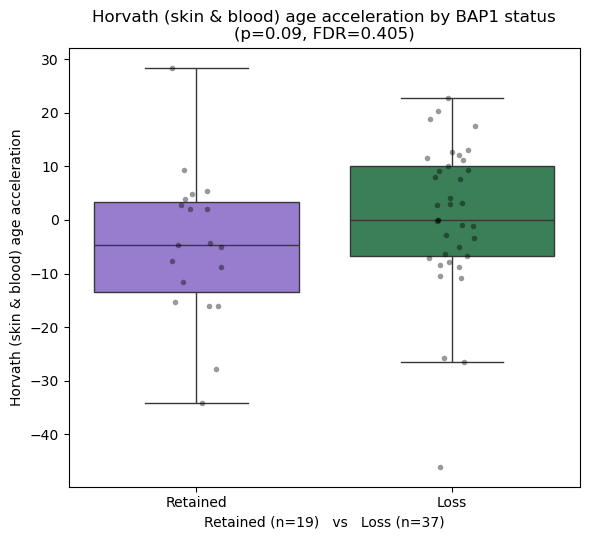

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Focus on the Horvath skin & blood clock because it showed the most
# consistent near-significant pattern across the survival and BAP1 analyses.
# This figure looks specifically at the BAP1 comparison.

df = pd.read_csv('/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv', low_memory=False)

# Set up the clock and BAP1 variables used for the comparison
clock_col = 'ageAcc.Hovarth2'
bap1_col = 'Overall BAP1 IHC (1=positive/retained, 0=negative/loss)'

df[clock_col] = pd.to_numeric(df[clock_col], errors='coerce')
df[bap1_col] = pd.to_numeric(df[bap1_col], errors='coerce')
df['BAP1_status'] = df[bap1_col].map({1: 'Retained', 0: 'Loss'})

# Keep only patients with both methylation and BAP1 data available
plot_df = df[[clock_col, 'BAP1_status']].dropna()

# Count the patients in each group for the figure label
n0 = (plot_df['BAP1_status'] == 'Retained').sum()
n1 = (plot_df['BAP1_status'] == 'Loss').sum()

# Plot the distribution of age acceleration by BAP1 status
fig, ax = plt.subplots(figsize=(6, 5.5))

sns.boxplot(
    data=plot_df,
    x='BAP1_status',
    y=clock_col,
    order=['Retained', 'Loss'],
    palette={'Retained': 'mediumpurple', 'Loss': 'seagreen'},
    showfliers=False,
    ax=ax
)

# Overlay the individual patient values
sns.stripplot(
    data=plot_df,
    x='BAP1_status',
    y=clock_col,
    order=['Retained', 'Loss'],
    color='black',
    alpha=0.4,
    size=4,
    ax=ax
)

# Add the statistical result and group sizes to the figure
ax.set_title(
    'Horvath (skin & blood) age acceleration by BAP1 status\n'
    '(p=0.09, FDR=0.405)'
)

ax.set_xlabel(f'Retained (n={n0})   vs   Loss (n={n1})')
ax.set_ylabel('Horvath (skin & blood) age acceleration')

# Save the finished figure
plt.tight_layout()
plt.savefig('figure_4_horvath_spotlight.png', dpi=300, bbox_inches='tight')

print('saved figure_horvath_spotlight.png')